In [24]:
import importlib
importlib.reload(util)

<module 'emulator.interpolator.util' from '\\\\wsl.localhost\\Ubuntu\\home\\mikel\\GitHub\\iip-emulator\\emulator\\interpolator\\util.py'>

In [25]:
from emulator.interpolator import util
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.stats

# Obtain samples
param_names = ['log_lsun', 't_exp', 'X', 'Z', 'n']
limits = [(8, 9), (9, 19), (0.55, 0.95), (5e-4, 5e-2), (4, 18)]
n = 10000
record_quantile = False

distribs = []
for min, max in limits:
    distribs.append(scipy.stats.uniform(min, max - min))

def prior_transform(cube):
    params = [distribs[i].ppf(cube[i]) for i in range(len(cube))]
    return params

# Create DataFrame
data = {}
for param in param_names:
    data[param] = []
    if record_quantile:
        data[param + '_u'] = []

for i in range(n):
    cube = np.random.rand(len(param_names))
    params = prior_transform(cube)
    for i, value in enumerate(params):
        param = param_names[i]
        data[param].append(value)
        if record_quantile:
            data[param + '_u'].append(cube[i])

df = pd.DataFrame(data)
df.index.name = 'id'

v_phot = util.calc_v_phot(t_exp=df['t_exp'].values, X=df['X'].values, n=df['n'].values)
# mask = (v_phot > 5800) & (v_phot < 10000)
# df = df[mask]
# df.reset_index(drop=True, inplace=True)
# df.index.name = 'id'

df.to_csv('grid.csv')

6020.8347352147475 11066.172004354197
10000


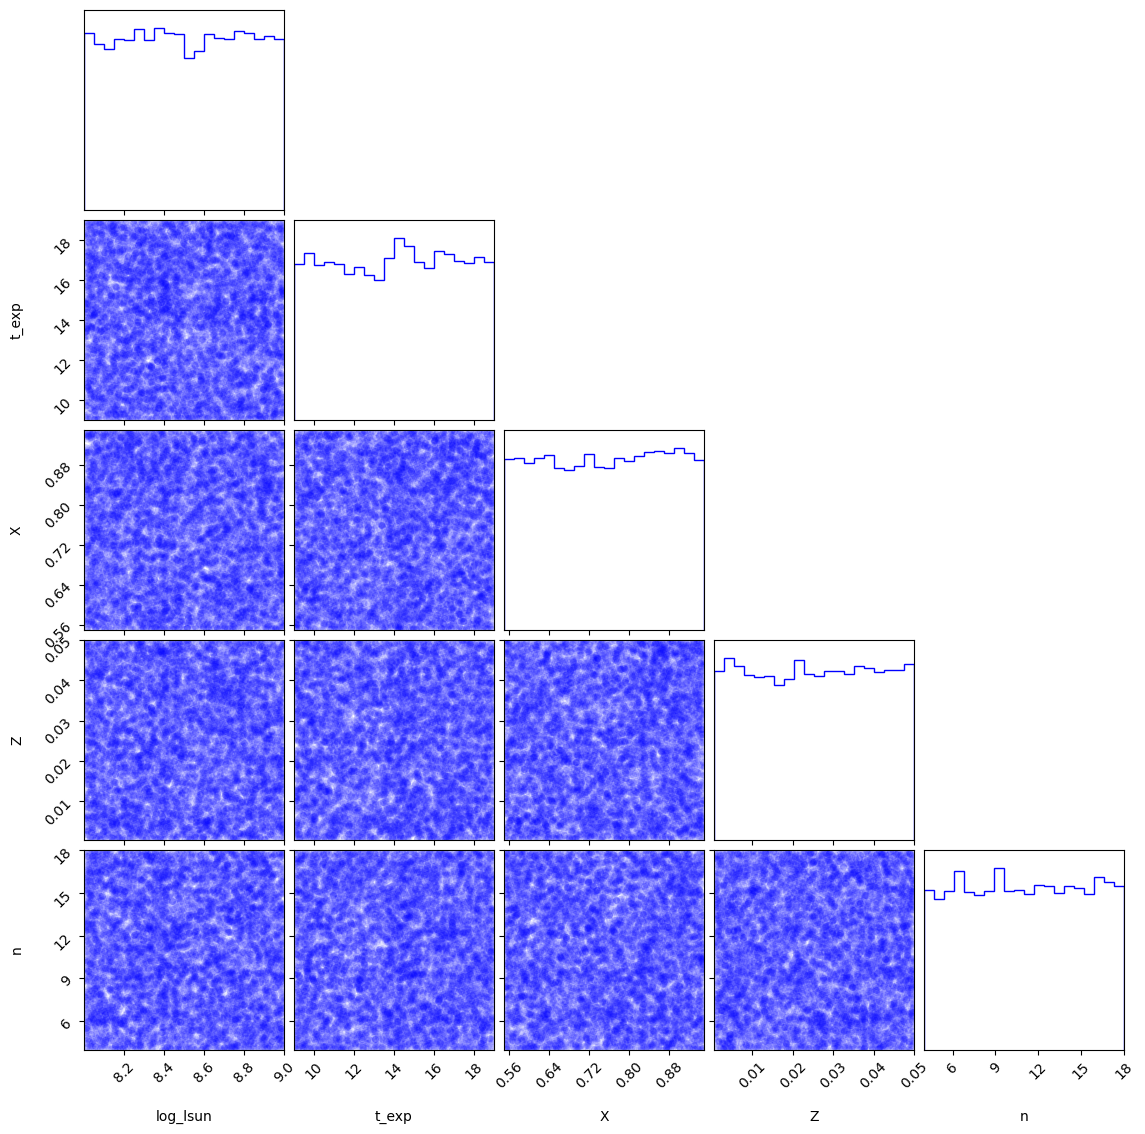

In [26]:
print(v_phot.min(), v_phot.max())
print(len(df))
import corner

fig = corner.corner(
    df[param_names].values,
    labels=param_names,
    range=limits,
    bins = 20,
    color='blue',
    plot_contours=False,
    plot_datapoints=True,
    plot_density=False,
    data_kwargs={'ms': 5}
)

In [ ]:
import pandas as pd
import numpy as np

# Seed samples for noise variation tests
n = 1000
seeds = np.random.randint(low=10000000, high=100000000, size=n)
virtual_packets = [3]*int(n/2) + [6]*int(n/2)

df = pd.DataFrame({'seed': seeds, 'virtual_packets': virtual_packets})
df.index.name = 'id'
df.to_csv('grid.csv')
